In [744]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [745]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScience_Projects/SupplyChain/supply_chain_data.csv")
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [746]:
# SKU is the identifier, make it into index
df.set_index("SKU", inplace = True)

### Dataset Overview

In [747]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, SKU0 to SKU99
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   Price                    100 non-null    float64
 2   Availability             100 non-null    int64  
 3   Number of products sold  100 non-null    int64  
 4   Revenue generated        100 non-null    float64
 5   Customer demographics    100 non-null    object 
 6   Stock levels             100 non-null    int64  
 7   Lead times               100 non-null    int64  
 8   Order quantities         100 non-null    int64  
 9   Shipping times           100 non-null    int64  
 10  Shipping carriers        100 non-null    object 
 11  Shipping costs           100 non-null    float64
 12  Supplier name            100 non-null    object 
 13  Location                 100 non-null    object 
 14  Lead time                1

In [748]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [749]:
df.duplicated().sum()

np.int64(0)

### Summary Statistics

In [750]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,100.0,49.462461,31.168193,1.699976,19.597823,51.239831,77.198228,99.171329
Availability,100.0,48.400000,30.743317,1.000000,22.750000,43.500000,75.000000,100.000000
Number of products sold,100.0,460.990000,303.780074,8.000000,184.250000,392.500000,704.250000,996.000000
Revenue generated,100.0,5776.048187,2732.841744,1061.618523,2812.847151,6006.352023,8253.976921,9866.465458
Stock levels,100.0,47.770000,31.369372,0.000000,16.750000,47.500000,73.000000,100.000000
Lead times,100.0,15.960000,8.785801,1.000000,8.000000,17.000000,24.000000,30.000000
Order quantities,100.0,49.220000,26.784429,1.000000,26.000000,52.000000,71.250000,96.000000
Shipping times,100.0,5.750000,2.724283,1.000000,3.750000,6.000000,8.000000,10.000000
Shipping costs,100.0,5.548149,2.651376,1.013487,3.540248,5.320534,7.601695,9.929816
Lead time,100.0,17.080000,8.846251,1.000000,10.000000,18.000000,25.000000,30.000000


In [751]:
df.describe(include="object").T

,count,unique,top,freq
Product type,100,3,skincare,40
Customer demographics,100,4,Unknown,31
Shipping carriers,100,3,Carrier B,43
Supplier name,100,5,Supplier 1,27
Location,100,5,Kolkata,25
Inspection results,100,3,Pending,41
Transportation modes,100,4,Road,29
Routes,100,3,Route A,43


### Numerical EDA

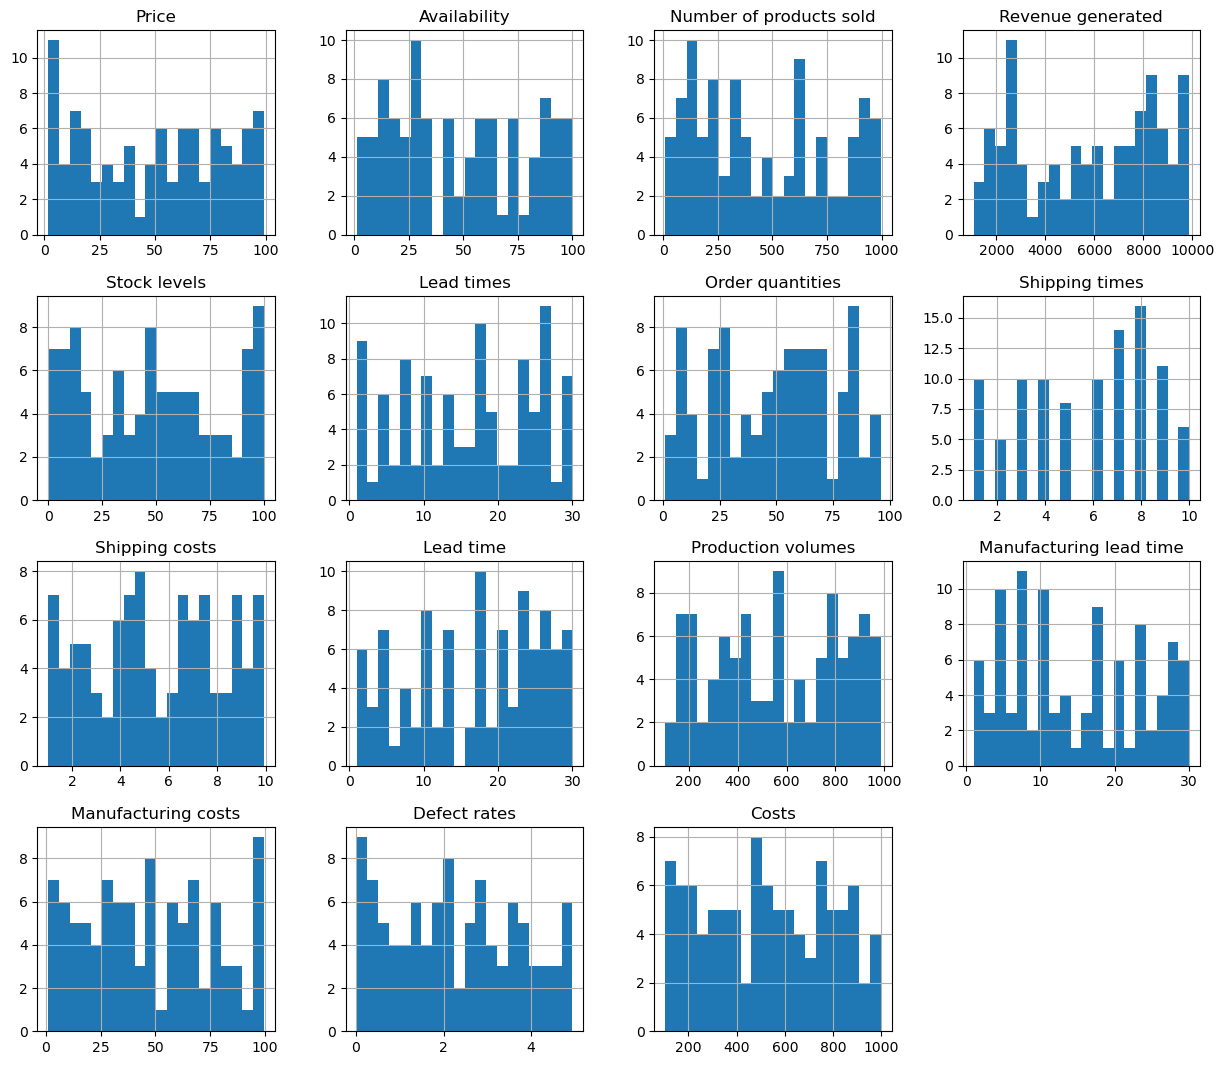

In [752]:
df.hist(figsize=(15,13), bins =20)
plt.show()

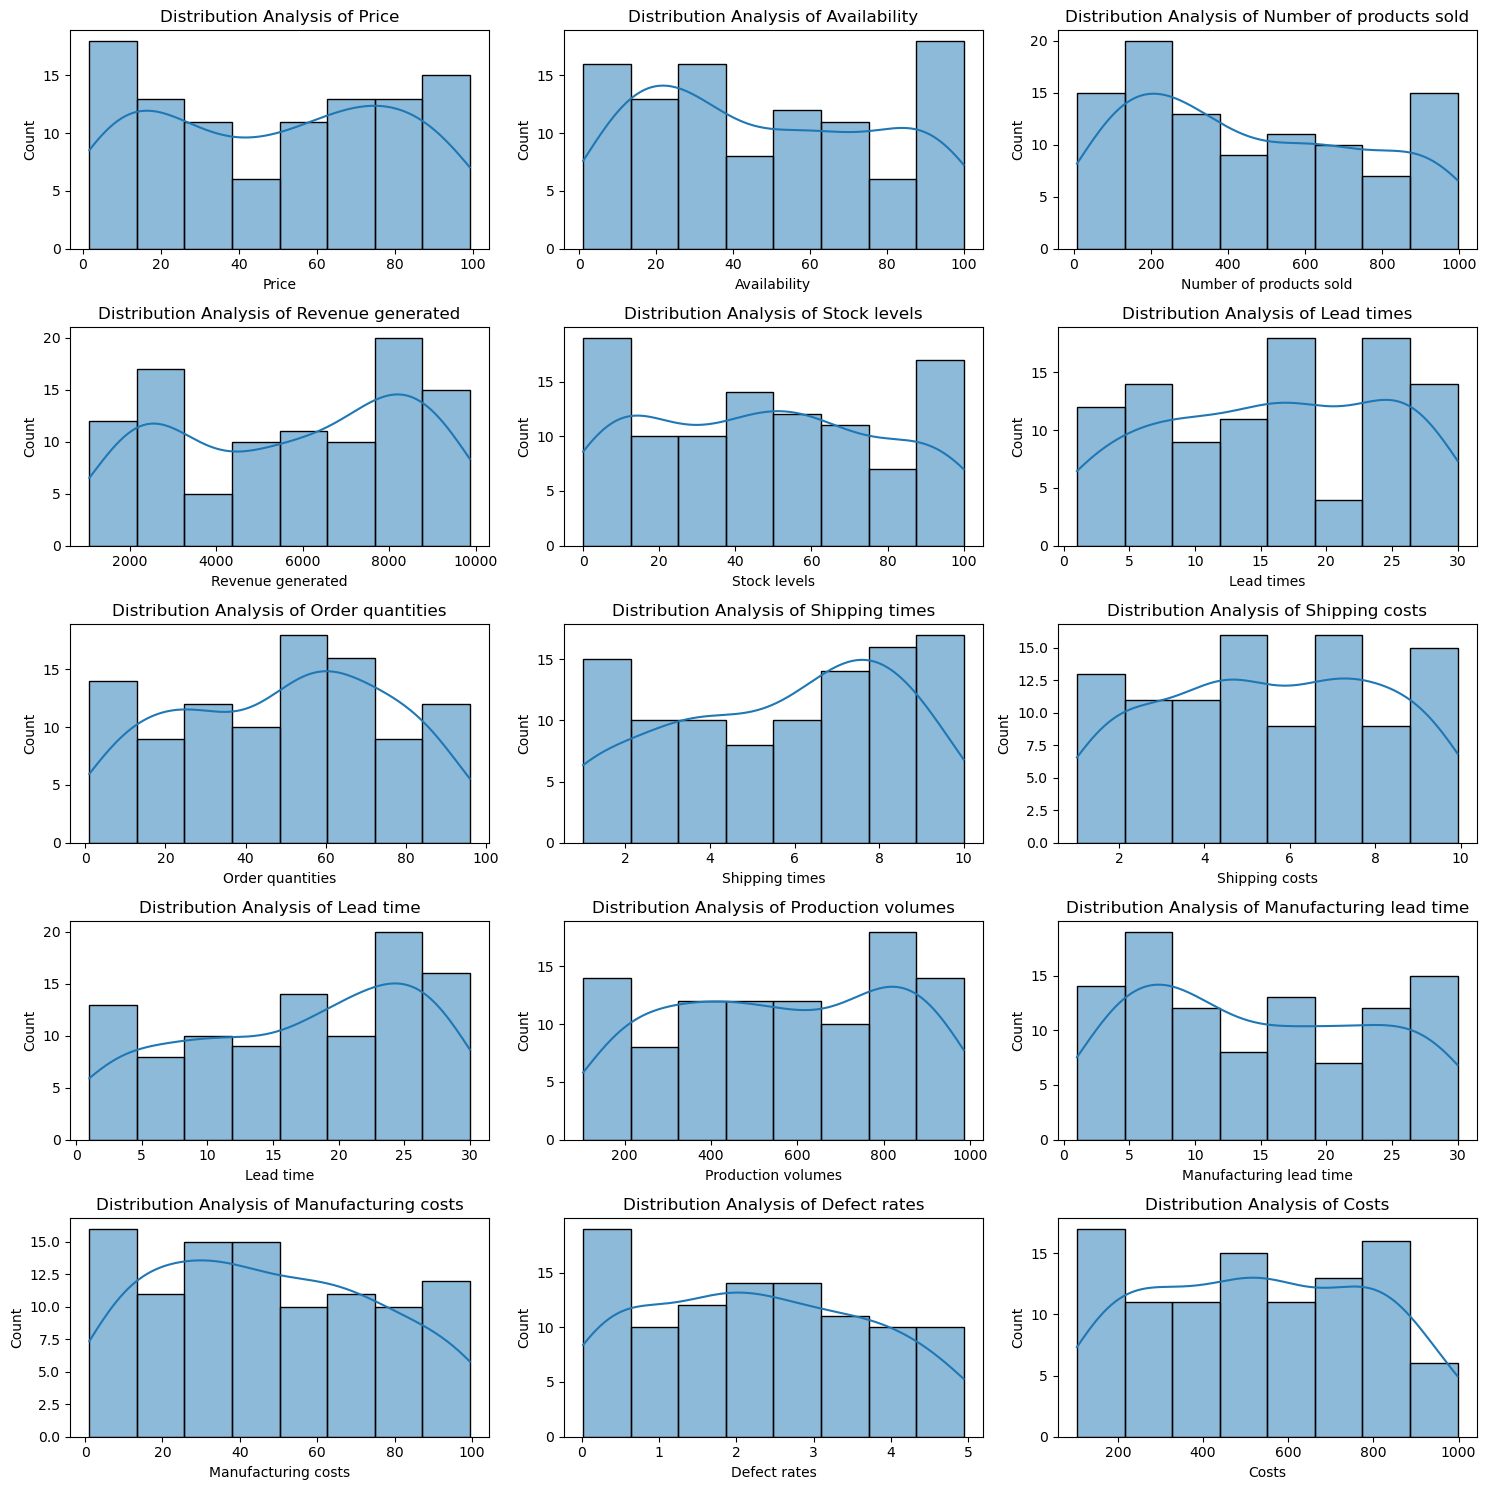

In [753]:
# Distribution Plot -> only for numerical columns

fig, axes = plt.subplots(5, 3, figsize = (15, 15))
axes = axes.flatten()

num_col = df.select_dtypes(include =  "number").columns
for i, j in enumerate(num_col):
    sns.histplot(df[j], kde = True, ax = axes[i])
    axes[i].set_title(f"Distribution Analysis of {j}")

plt.tight_layout()
plt.show()


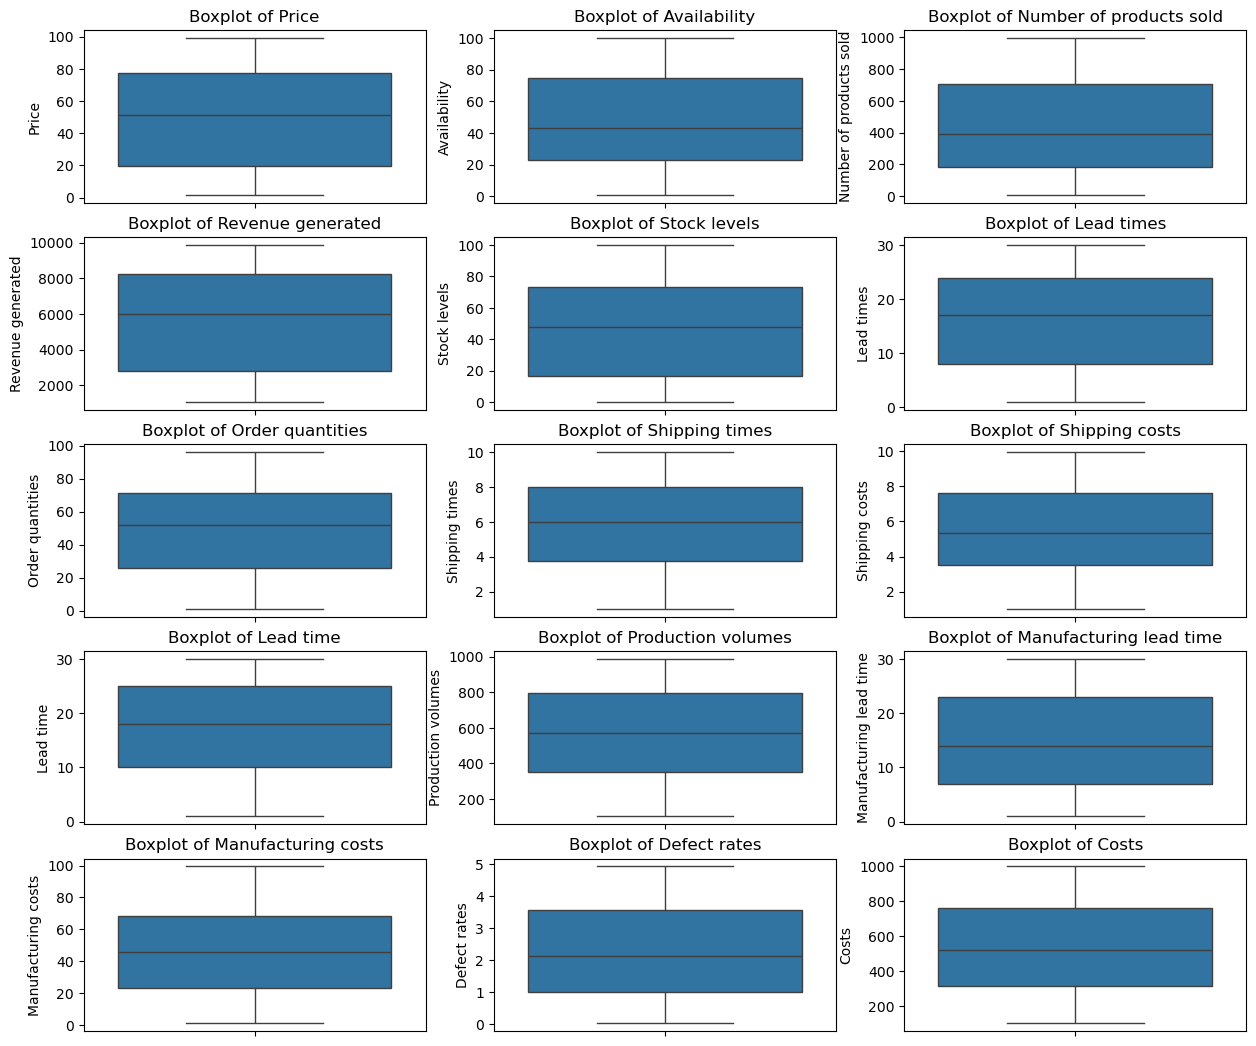

In [754]:
## Boxplot 
fig, axes = plt.subplots(5, 3 , figsize = (15, 13))
axes = axes.flatten()

for i, j in enumerate(num_col):
    sns.boxplot(df[j], ax = axes[i])
    axes[i].set_title(f"Boxplot of {j}")

plt.show()

In [755]:
## correlation matrix

### Categorical EDA
- value count
- count plot

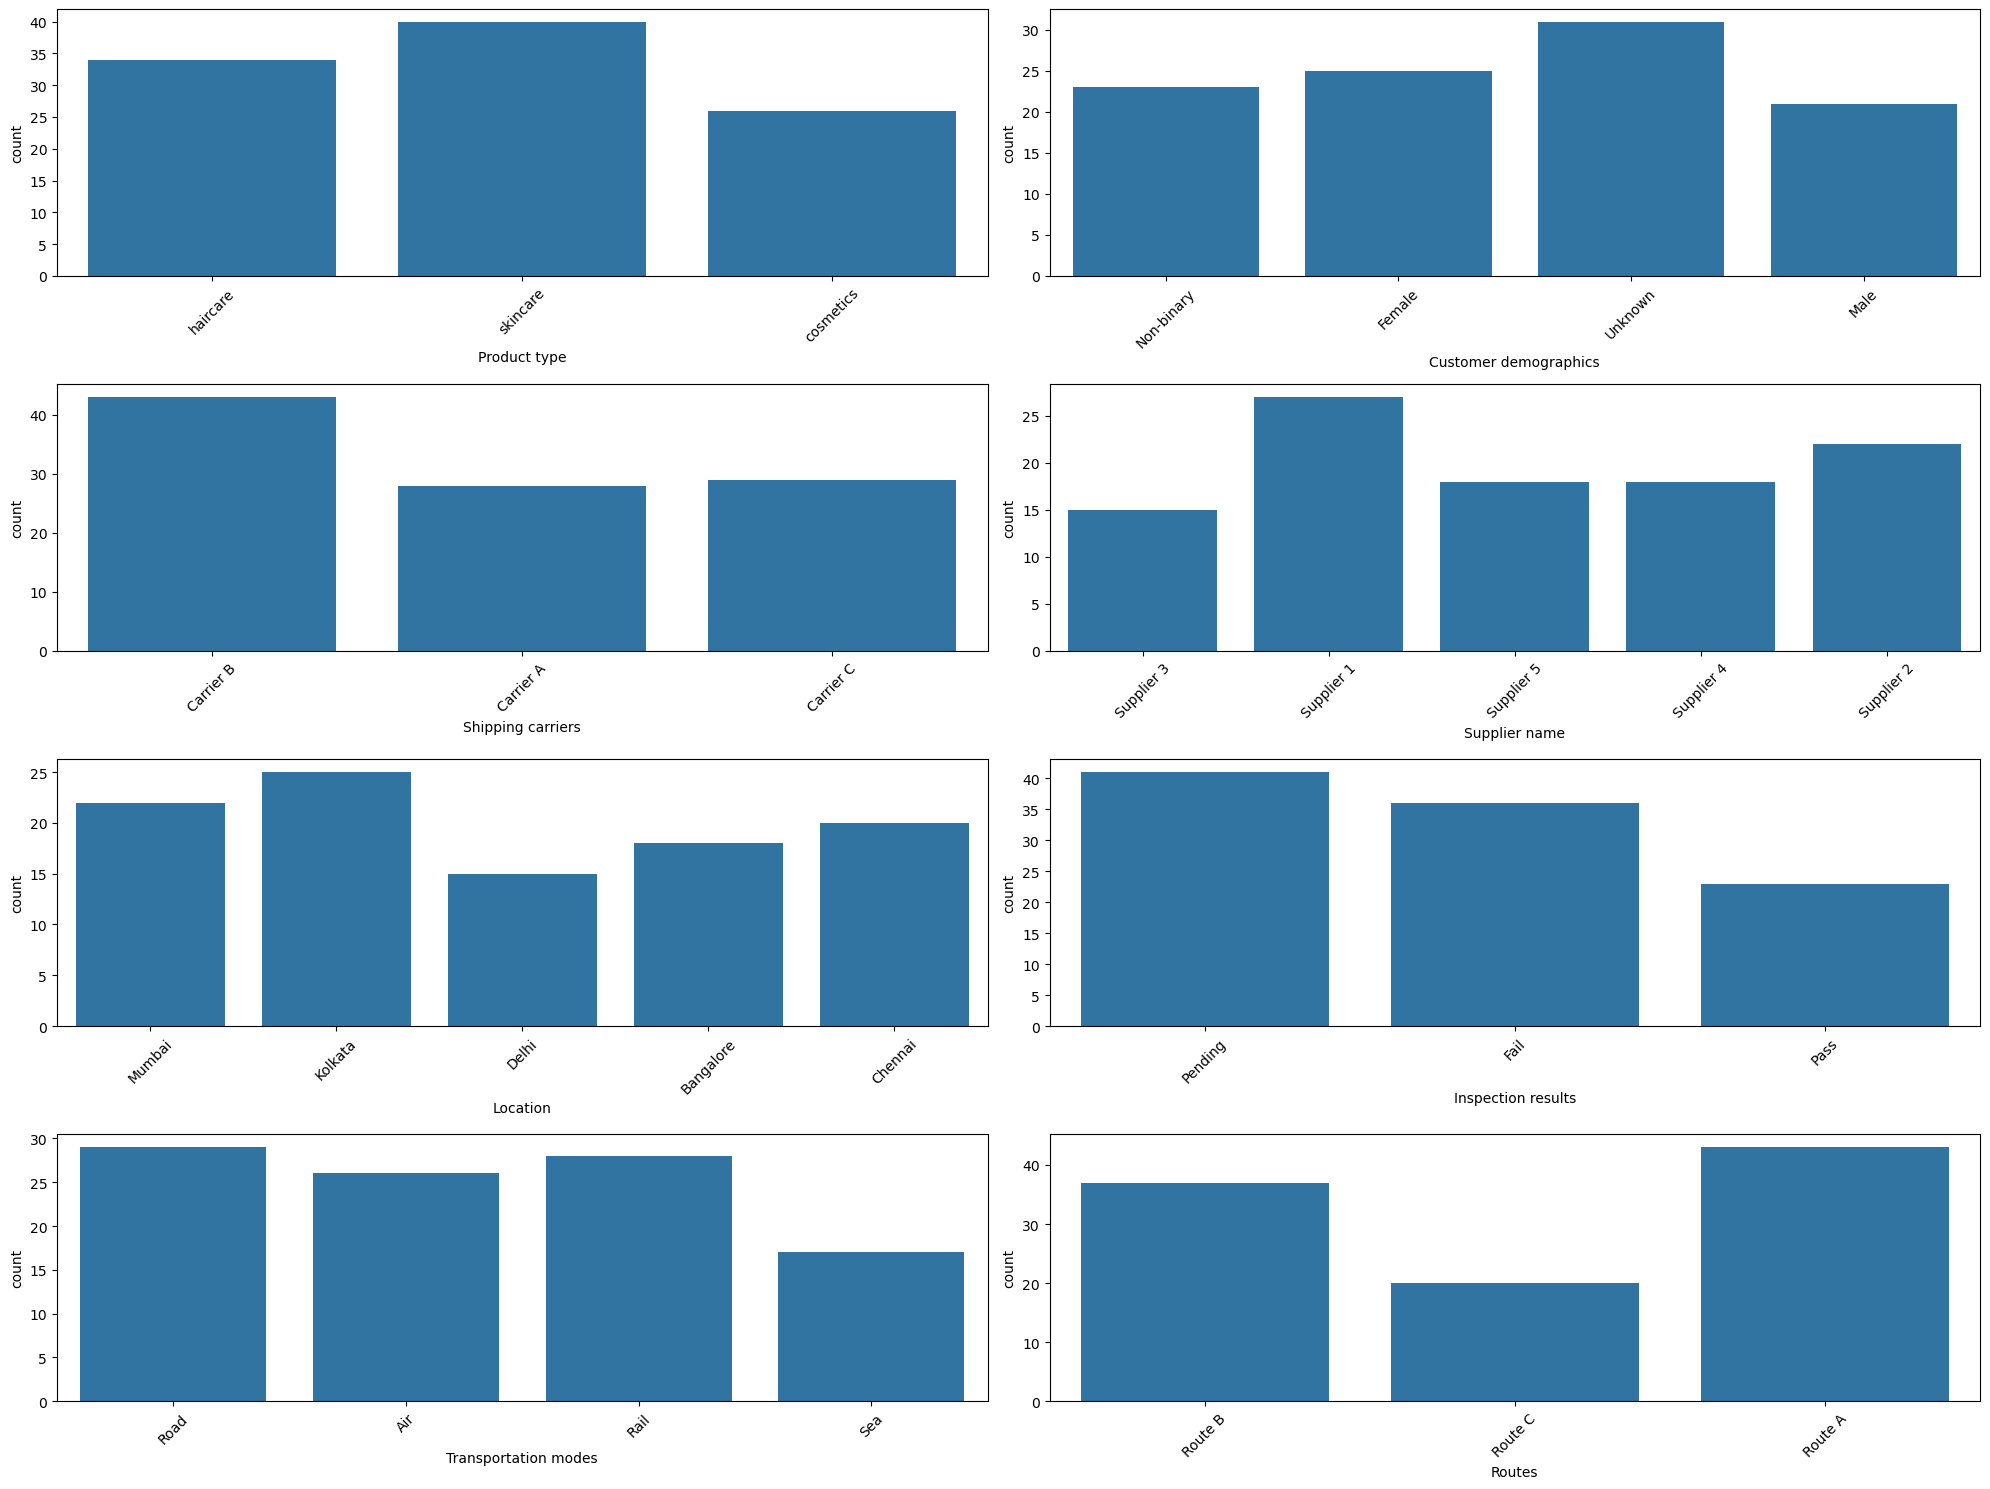

In [756]:
## Count plot - for categorical variables
fig, axes = plt.subplots(4, 2, figsize = (20, 15))
axes = axes.flatten()

cat_col = df.select_dtypes(include = "object").columns

for i, j in enumerate(cat_col):
    sns.countplot(
        data=df,
        x = j,
        ax = axes[i]
    )
    axes[i].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()

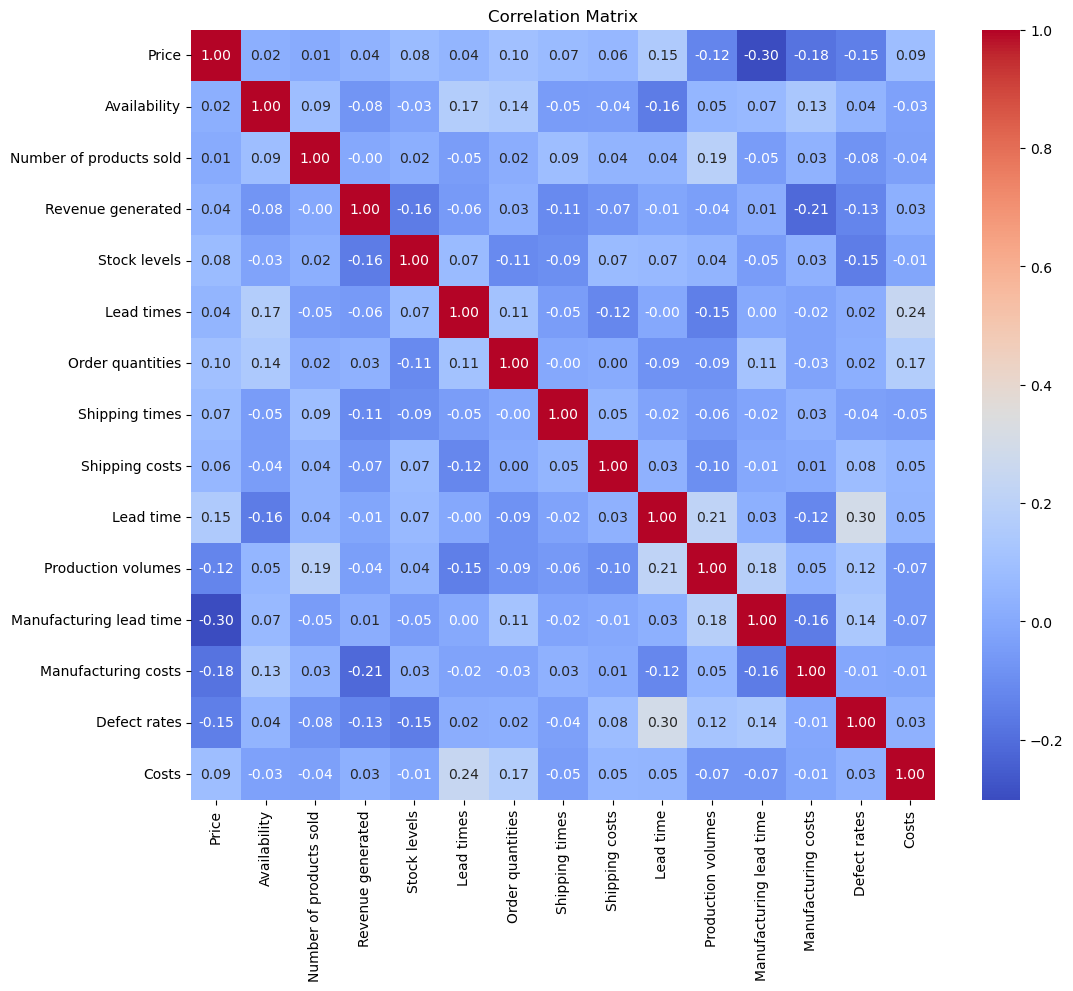

In [757]:
plt.figure(figsize=(12,10))

corr = df[num_col].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Relationship Analysis
- scatter plot
- pairplot

outlier detection 
kurtosis 
skewness


## Logistic Regression: Supply Chain Risk Score
- estimate the overall operational risk of a product
- High Defect = 1 --> High defect rate
- High Defect = 0 --> Low defect rate

In [758]:
print(df['Defect rates'].describe())
print(df['Defect rates'].median())


count    100.000000
mean       2.277158
std        1.461366
min        0.018608
25%        1.009650
50%        2.141863
75%        3.563995
max        4.939255
Name: Defect rates, dtype: float64
2.141862683349868


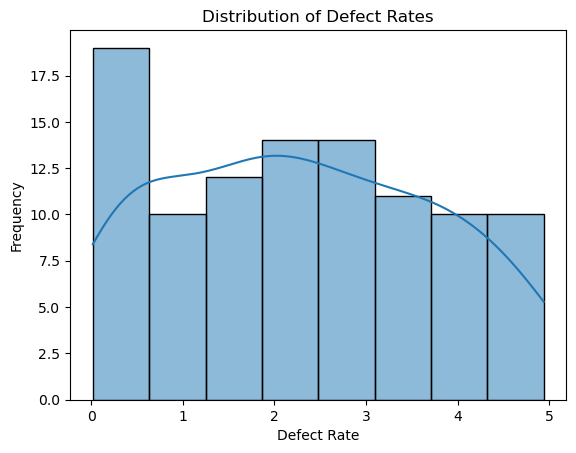

In [759]:
sns.histplot(
    df['Defect rates'],
    kde = True
)

plt.title("Distribution of Defect Rates")
plt.xlabel("Defect Rate")
plt.ylabel("Frequency")
plt.show()

In [760]:
threshold = df['Defect rates'].median()

df['High defect'] = (
    df['Defect rates'] >= threshold
).astype(int)

In [761]:
df['High defect'].value_counts(normalize=True)

High defect
0    0.5
1    0.5
Name: proportion, dtype: float64

In [762]:
## checking if the predictors have relationships with defect rate

numerical_cols = df.select_dtypes(include = "number").columns

corr = (
    df[numerical_cols]
    .corr()['Defect rates']
    .sort_values(ascending=False)
)

print(corr)

Defect rates               1.000000
High defect                0.852554
Lead time                  0.297099
Manufacturing lead time    0.139518
Production volumes         0.118853
Shipping costs             0.083139
Availability               0.040626
Costs                      0.032072
Order quantities           0.018986
Lead times                 0.015681
Manufacturing costs       -0.007819
Shipping times            -0.036673
Number of products sold   -0.082726
Revenue generated         -0.125335
Price                     -0.147247
Stock levels              -0.149478
Name: Defect rates, dtype: float64


IndexError: index 9 is out of bounds for axis 0 with size 9

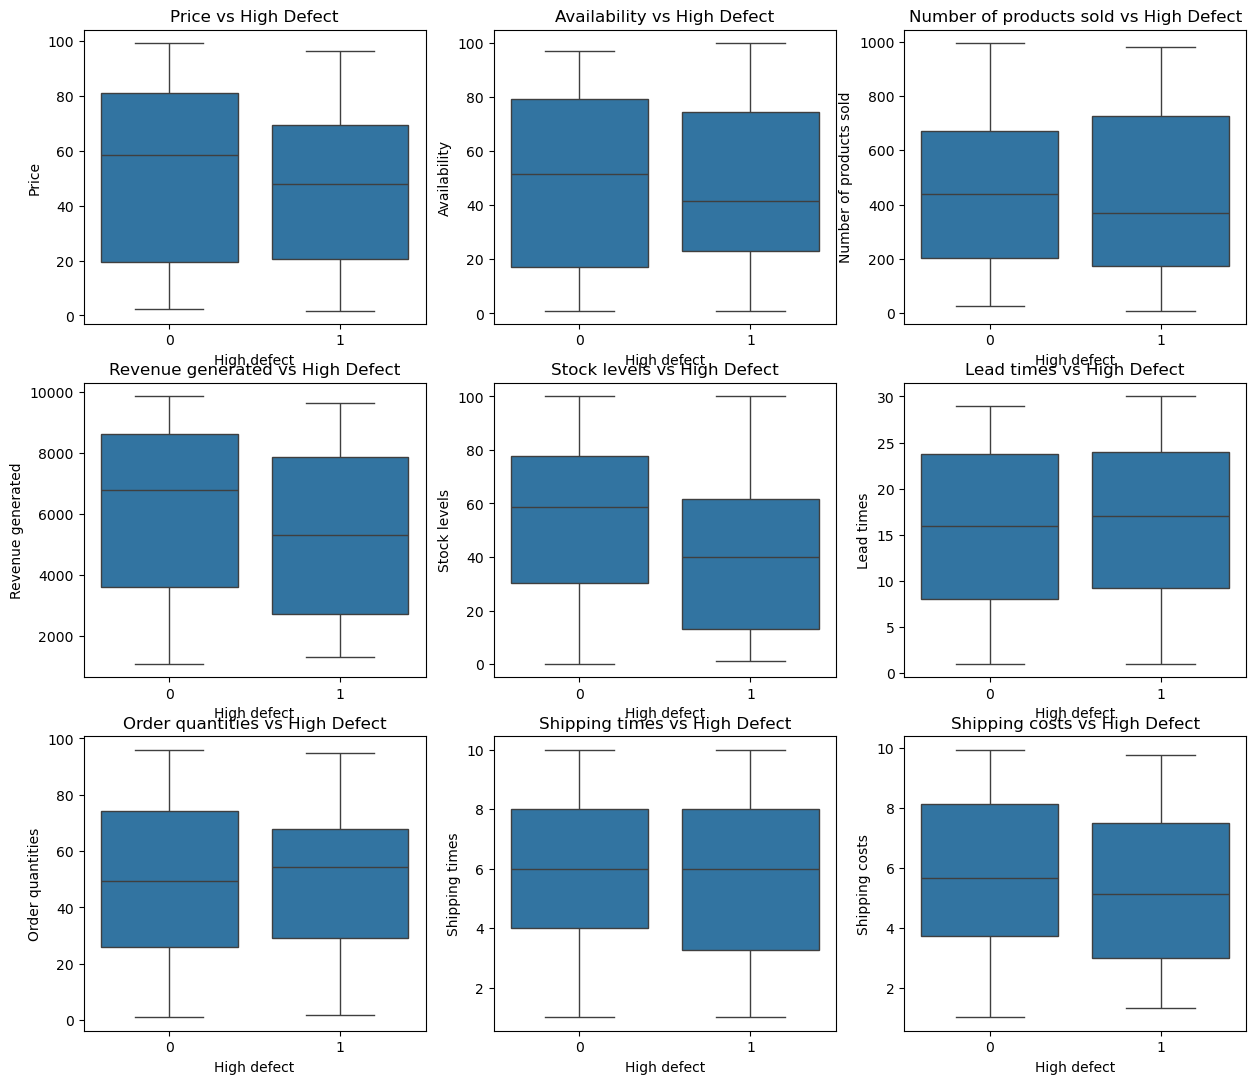

In [763]:
# Numerical variables vs High Defect

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.boxplot(
        data=df,
        x="High defect",
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs High Defect")

# Remove unused axes
for i in range(len(num_col), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

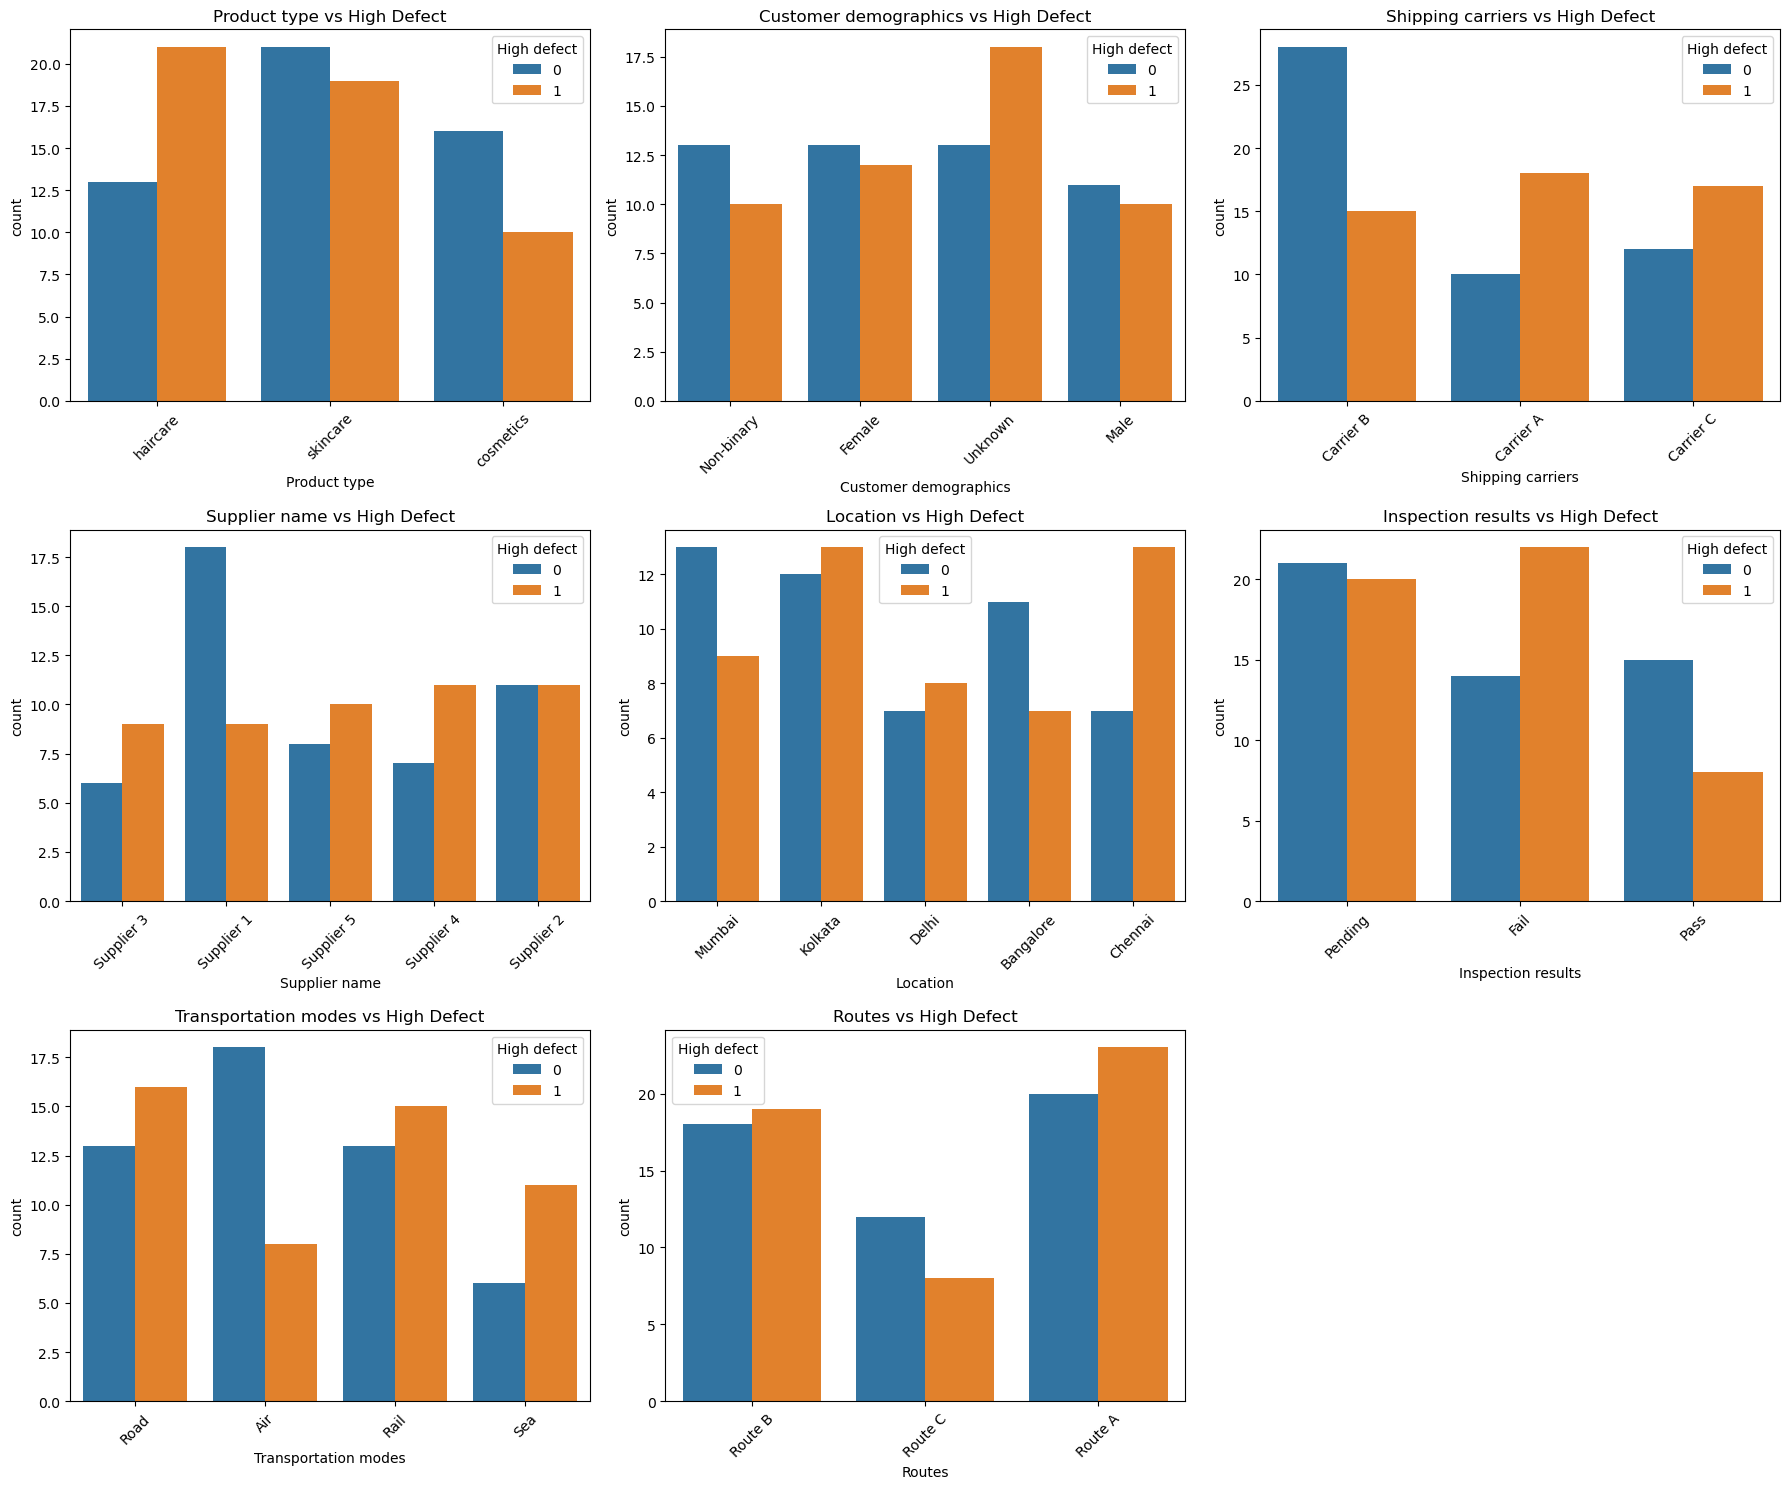

In [764]:
cat_col = df.select_dtypes(
    include=["object", "category"]
).columns

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(
        data=df,
        x=col,
        hue="High defect",
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs High Defect")
    axes[i].tick_params(axis="x", rotation=45)

for i in range(len(cat_col), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()